# Predictive Analytics Task

Here, I focus on Task 3: **Classification Challenge**. 

In this task, we are asked to classify a Hex in'sr_hex.csv' as either **sparsely** of **densely** populated, using only the service request data that is associated with the hext for each service request submission. 

This is an **unsupervised** classification problem where we know the total number of outcomes/labels (2: sparsely or densely populated), but we don't have the label for each hex. The crux of the problem is in using the value contained in the rest of the service request data to make an informed decision around the (relative) population of the hex.

To approach the problem thoughtfully, let's jump in and have a look at the dataset and investigate features and distributions. The outcome of these tasks will inform significantly our classification strategy.

## 1. Data preparation

In [1]:
# Imports

import gzip
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Red file in -- file is compressed to use gzip compression.

file_loc = "/Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/sr_hex.csv.gz"
df = pd.read_csv(file_loc, compression="gzip")

File has been read in: Let's investigate with basic metrics. 

In [5]:
df.shape # almost 1M rows, and 16 columns. Let's see what the columns are:

(941634, 16)

In [6]:
df.head()

,notification_number,reference_number,creation_timestamp,completion_timestamp,directorate,department,branch,section,code_group,code,cause_code_group,cause_code,official_suburb,latitude,longitude,h3_level8_index
0,400583534,9.109492e+09,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area Central,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Wear and tear,MONTAGUE GARDENS,-33.872839,18.522488,88ad360225fffff
1,400555043,9.108995e+09,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,SOMERSET WEST,-34.078916,18.848940,88ad36d5e1fffff
2,400589145,9.109614e+09,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area East,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,Road (RCL),Vandalism,STRAND,-34.102242,18.821116,88ad36d437fffff
3,400538915,9.108601e+09,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area North,District : Bellville,TD Customer complaint groups,Paint Markings Lines&Signs,Road Markings,Wear and tear,RAVENSMEAD,-33.920019,18.607209,88ad361133fffff
4,400568554,NaN,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,RIM Area South,District : Athlone,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,Road (RCL),Surfacing failure,CLAREMONT,-33.987400,18.453760,88ad361709fffff


So we have a dataset that links a **Service Request (SR)** :
* "notification_number"
* "reference_number"
* "creation_timestamp"

to the time it was completed:
* "completion_timestamp",

with info around the type of request in what appears to be a heirarchical manner:
* "directorate"
* "branch"
* "code_group"
* "code"
* "cause_code_group"
* "cause_code"

I'm not certain as to how these relate to each other, however. We also have some spatial information around the service request:
* "latitude"
* "longitude"
* "h3_level8_index"

Each row is a unique service request; so in essence we are capturing information around the time of the SR, the nature of the SR, and the area. 

Let's inspect if there are any missing values:

In [3]:
df.isna().sum()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


notification_number          0
reference_number        348714
creation_timestamp           0
completion_timestamp     12192
directorate               9435
department                9454
branch                   28401
section                  93125
code_group                   0
code                         0
cause_code_group        810517
cause_code              811965
official_suburb         212413
latitude                212364
longitude               212364
h3_level8_index              0
dtype: int64

Wow! Many more NAs that I was expecting. We are going to have to deal with these somehow.

* reference number not strictly needed for analysis, so can omit it. 
* I'll need completion timestamp to calculate time to resolve issues, so must remove NAs here
* remove NAs in directorate and department (as there are few)
* section seems to be linked to location, so I should keep it in and remove NAs. 
* Many NAs in cause_code and cause, almost 100% of the total row number, so will remove and ignore.
* I need lat and long to plot through space, so will remove NAs here.

Let me remove the NAs first and then I can inspect the data in more detail. 

In [4]:
# first remove lat + long --
# I'm curious to see if lat long pairs are excluded at the same time or there is some assymetry (i.e., NA in long but not in lat for a SR)
# If the latter is true, it may prove difficult for the rest of the analysis. 

dfx = df[(~df['latitude'].isna()) & (~df['longitude'].isna())]
dfx.shape

(729270, 16)

In [5]:
941634 - 729270 # 212364 -- lat and long pairs are missing, not individual lat and long values -- good -- makes analysis easier. 

212364

In [6]:
# Remove the rest of the NAs
dfy = dfx[(~dfx['directorate'].isna()) & 
          (~dfx['department'].isna()) & 
          (~dfx['completion_timestamp'].isna()) & 
          (~dfx['section'].isna()) & 
          (~dfx['branch'].isna()) &  
          (~dfx['department'].isna())]

# Select the variables of interest (remove 
dfz = dfy[['notification_number','creation_timestamp','completion_timestamp','directorate','department', 'section', 'code_group', 
        'code', 'latitude', 'longitude', 'official_suburb', 'h3_level8_index']]
dfz.shape

(654142, 12)

OK, so the DF has decreased in row number from 941 634 in the raw data, to 654 142, ~70% of its original row size. That's fine, I'm happy to proceed, we have't lost massive data by removing NAs. 

## 2. Exploratory Data Investigation

I want to check how the **spatial** and **info** variables are structured. Let me examine some data. 

### 2.1. Hex investigation

In [7]:
# How many hexs do we have?
dfz['h3_level8_index'].unique() 

<StringArray>
['88ad360225fffff', '88ad36d5e1fffff', '88ad36d437fffff', '88ad361133fffff',
 '88ad361709fffff', '88ad36d43dfffff', '88ad361a19fffff', '88ad3611edfffff',
 '88ad361519fffff', '88ad3618e5fffff',
 ...
 '88ad368519fffff', '88ad360aebfffff', '88ad361987fffff', '88ad361999fffff',
 '88ad361469fffff', '88ad367289fffff', '88ad3672c3fffff', '88ad361627fffff',
 '88ad361895fffff', '88ad36d71bfffff']
Length: 2013, dtype: str

In [8]:
# How many official suburbs do we have

dfz['official_suburb'].unique() 

<StringArray>
[               'MONTAGUE GARDENS',                   'SOMERSET WEST',
                          'STRAND',                      'RAVENSMEAD',
                       'CLAREMONT',                       'GLENHAVEN',
           'CAPE TOWN CITY CENTRE',                     'DURBANVILLE',
                       'CONNAUGHT',                      'BO OAKDALE',
 ...
 'STELLENBOSCH FARMS (BLUE DOWNS)',                       'VOGELVLEI',
                     'ACACIA PARK',              'BELLVILLE LANDFILL',
      'BELLVILLE TEACHERS COLLEGE',                       'SAXONWOOD',
                   'ROBBEN ISLAND',                      'DREAMWORLD',
       'BOTTELARY SMALLHOLDINGS 1',                  'WELMOED ESTATE']
Length: 775, dtype: str

In [9]:
# How many sections?

dfz['section'].unique() 

<StringArray>
[                                  'District: Blaauwberg',
                               'District : Somerset West',
                                   'District : Bellville',
                                     'District : Athlone',
                                    'District: Cape Town',
                                'District : Kraaifontein',
                                 'District : Khayelitsha',
                                   'District : Plumstead',
                                 'CTE Distribution South',
                        'Reticulation Water Distribution',
                                 'CTE Distribution North',
                                        'Debt Management',
                                           'Area Central',
                                             'Area South',
                                  'CTE Distribution East',
                                 'Area Central Parks 3.1',
                                 'Area Cen

So **2013** Hexs, **775** official suburbs, and **76** sections. I suspect these are heirarchical, in the sense that Hexs are the lowest granularity, and each Hex is nested inside an official suburb, which itself is nested in Section. 

We could quickly check this -- each hex should only have 1 surburb, if they are nested in suburbs. 

In [10]:
dfz.groupby(['h3_level8_index'])['official_suburb'].nunique().value_counts()

official_suburb
1    929
2    492
3    275
4    184
5     72
6     30
7     18
8      9
9      2
0      2
Name: count, dtype: int64

This isn't what I observe, however. Most of the Hexs are in one suburb, so there's strong evidence for a 1:1 relationship between suburbs and Hexes but quite a few belong to two unique suburbs. So a Hex must be bigger than an official suburb (in terms of geographic size). I think the way Hexes are structured over existing suburbs means that there will at times be more tha one suburb per hex; a hex is a fixed size but suburbs are not, hence the mismatch. 

Let's see how Hexes relate to sections -- again, I assume that Hexes are nested inside a section, and each Hex can belong to one and only one Surburb:

In [11]:
dfz.groupby(['h3_level8_index'])['section'].nunique().value_counts()

section
1     303
2     137
23    121
24     96
21     92
18     87
19     85
22     83
20     80
25     73
17     70
3      68
16     62
26     61
4      56
15     55
14     55
10     41
27     41
5      39
9      37
12     36
7      33
6      32
28     32
11     31
13     30
8      26
30     19
29     16
31     10
32      5
52      1
Name: count, dtype: int64

Ah ok, so this again isn't what I observe. OK, so the relationship between Hex and Surburb, and Hex and Section is not linear and heirarchical. I'm not sure how they actually relate to each other, but it seems complex, and I think for this Challenge Analysis, it's enough to acknowledge the many-to-many relationship. 

Let me see how Section and Suburb are related:

In [12]:
dfz.groupby(['official_suburb'])['section'].nunique().value_counts()

section
23    42
21    40
18    38
19    36
20    34
14    34
17    34
13    34
16    31
15    31
25    30
22    29
24    27
28    25
26    25
30    23
11    22
27    21
12    20
9     18
29    18
10    17
8     16
32    15
6     14
3     13
4     13
31    12
5     10
7     10
36     9
34     7
33     7
2      5
1      3
35     3
38     2
39     2
53     1
44     1
37     1
43     1
Name: count, dtype: int64

Ah, OK, I was expecting each suburb to have one section, but that's not what I see. So one suburb overlays many sections, it seems. Again, the relationship between Hex, Surburb, and Section aren't as straightforward as I'd thought. But it's still important to know how information is coded and related: There are more unique levels in suburb (775), whilst section only has 75 unique sections, so I think Section must describe a greater Geographic area than Suburb. And a Hex grid is overlayed on this. 

## 2.2 SR Information

Let me quickly look at the "Info" of each SR. 

In [13]:
# Directorate

dfz['directorate'].value_counts(), dfz['directorate'].nunique()

(directorate
 WATER AND SANITATION                348127
 ENERGY                              188219
 URBAN WASTE MANAGEMENT               57524
 FINANCE                              22468
 COMMUNITY SERVICES AND HEALTH        17794
 HUMAN SETTLEMENTS                     9959
 URBAN MOBILITY                        9121
 SAFETY AND SECURITY                    924
 ECONOMIC GROWTH                          5
 SPATIAL PLANNING AND ENVIRONMENT         1
 Name: count, dtype: int64,
 10)

Most in Water and Sanitation. 10 Unique elements. 

In [14]:
# Department

dfz['department'].value_counts(), dfz['department'].nunique()

(department
 Distribution Services                                            211586
 Electricity Generation and Distribution                          188219
 Commercial Services                                              131907
 Solid Waste Management                                            57524
 Revenue                                                           22468
 Recreation and Parks                                              14555
 Home Ownership Transfer, Tenancy Management and Staff Housing      9959
 Roads Infrastructure Management                                    7636
 Technical Services                                                 4633
 City Health                                                        2603
 Transport Planning & Network Management                            1485
 Operational Coordination                                            924
 Social Development & Early Childhood Development                    636
 Property Management                   

Most in Distribution Services, but Electricity Generation and Distribution contributes too. 16 Uniqe elements. 

In [15]:
# Let's see how Department and Directorate relate to each other

dfz.groupby(['department'])['directorate'].nunique().value_counts()

directorate
1    16
Name: count, dtype: int64

So each Department level relates back to one and only one Directorate level. There are more Department levels than Directorate. So the Heirarchy of information from high-to-low granularity is Directorate -> Department. 

In [16]:
# Let's examine code now.

dfz['code'].value_counts(), dfz['code'].nunique()

(code
 Sewer: Blocked/Overflow                108140
 No Power                                77776
 No Water WMD                            47601
 Customer : Reconnection Request         22294
 Street Lights - Single Light Out        21553
                                         ...  
 REnewal of Drivers License                  1
 Signals out of Sync at Intersection         1
 Green Electricity                           1
 OSL - Escalation Level 2                    1
 DO NOT USE Propert Zoning Request           1
 Name: count, Length: 376, dtype: int64,
 376)

In [17]:
# And code group. 

dfz['code_group'].value_counts(), dfz['code_group'].nunique()

(code_group
 ELECTRICITY TECHNICAL COMPLAINTS            157424
 SEWER                                       119579
 WATER                                        90525
 WATER MANAGEMENT DEVICE                      70467
 SOLID WASTE                                  57829
 WATER AND SANITATION OR METER QUERIES        54746
 REVENUE                                      22313
 ELECTRICITY FINANCIAL AND METER READING      16214
 CITY PARKS                                   14491
 HOUSING - EXISTING                            9961
 ELECTRICITY INTERNAL(REVENUE PROTECTION)      9233
 TD Customer complaint groups                  7548
 SEWER - INFORMAL SETTLEMENTS                  5547
 ELECTRICITY INTERNAL (GENERAL)                5250
 WATER  - INFORMAL SETTLEMENTS                 3240
 WATER - ALTERNATIVE SYSTEM APPLICATION        2706
 HEALTH                                        2566
 TRAFFIC SIGNALS                               1463
 WATER RESTRICTIONS                            1178


376 unique code levels, and 35 code group levels. I suspect that each code value belongs to one and only one code group level. Let's check. 

In [18]:
# Lets see how code and code group are related:

dfz.groupby(['code'])['code_group'].nunique().value_counts()

code_group
1    375
2      1
Name: count, dtype: int64

OK, this is at least what I expect. Each code belongs to 1 code group (except for 1). Meaning that all the info contained in Code Group is also contained in Code, so the hierarchy of information from high-to-low granulatiry is Code -> Code_Group. 

## 3. Implementation

### Strategy

OK, so far we have investigated the data. There are three main 'types' of information contained in the dataset: **Spatial** (Hex, Suburb, and Section), **SR Info** (code, code_group, directorate, and department), and **SR ticket creation** (creation_timestamp and completion_timestamp). 

We found some non-linear patterns in the variables that code for space (Hex, Section, Suburb), whilst we have more linear information flow with respect to the variables that code for SR Information (code, code_group, directorate, department), and we still have the information about ticket creation times. 

Our task operates at the **hex level**: we need a method to determine whether a given hex should be classified as **sparsely** or **densely** populated.

Importantly, this is a **relative measure**. The dataset does not provide an absolute definition of population density, so a hex can only be considered sparse or dense **in comparison to other hexes in the same geographic area**.

Rather than evaluating each hex in isolation, we  construct a scoring mechanism based on the service request data associated with each hex. This score captures the relative population level of activity within each hex. 

Once all hexes are scored, we can use the distribution of these scores to separate hexes into **sparse** and **dense** population categories.

### Analysis

Let's first engineer a feature. Since we have the timestamp a SR was submitted, and the time it was completed, we can calculate completion time: 

In [19]:
# Time to resolve
dfz['creation_timestamp'] = pd.to_datetime(dfz['creation_timestamp'])
dfz['completion_timestamp'] = pd.to_datetime(dfz['completion_timestamp'])
dfz['completion_time_hours'] = (dfz['completion_timestamp'] - dfz['creation_timestamp']).dt.total_seconds() / 3600
dfz.head()

,notification_number,creation_timestamp,completion_timestamp,directorate,department,section,code_group,code,latitude,longitude,official_suburb,h3_level8_index,completion_time_hours
0,400583534,2020-10-07 06:55:18+02:00,2020-10-08 15:36:35+02:00,URBAN MOBILITY,Roads Infrastructure Management,District: Blaauwberg,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,-33.872839,18.522488,MONTAGUE GARDENS,88ad360225fffff,32.688056
1,400555043,2020-07-09 16:08:13+02:00,2020-07-14 14:27:01+02:00,URBAN MOBILITY,Roads Infrastructure Management,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,-34.078916,18.848940,SOMERSET WEST,88ad36d5e1fffff,118.313333
2,400589145,2020-10-27 10:21:59+02:00,2020-10-28 17:48:15+02:00,URBAN MOBILITY,Roads Infrastructure Management,District : Somerset West,TD Customer complaint groups,Manhole Cover/Gully Grid,-34.102242,18.821116,STRAND,88ad36d437fffff,31.437778
3,400538915,2020-03-19 06:36:06+02:00,2021-03-29 20:34:19+02:00,URBAN MOBILITY,Roads Infrastructure Management,District : Bellville,TD Customer complaint groups,Paint Markings Lines&Signs,-33.920019,18.607209,RAVENSMEAD,88ad361133fffff,9013.970278
4,400568554,2020-08-25 09:48:42+02:00,2020-08-31 08:41:13+02:00,URBAN MOBILITY,Roads Infrastructure Management,District : Athlone,TD Customer complaint groups,Pothole&Defect Road Foot Bic Way/Kerbs,-33.987400,18.453760,CLAREMONT,88ad361709fffff,142.875278


Our analysis must be on the Hex level. Thus, we must aggregate the information at the Hex level. Here is the key of the analysis.

### Working Assumptions

I introduce several simplifying assumptions that allow service request (SR) activity to act as a proxy for population density.

* I assume that the number of service requests generated in a hex is broadly **proportional to the number of people living in that hex**. In other words, more populated areas should tend to generate more service requests.

* I assume that the **propensity to submit service requests is roughly constant across the geographic area**. This means that residents in one hex are not systematically more or less likely to submit service requests than residents in another.

* I assume that the **distribution of service request types (`code_group`) does not systematically bias certain hexes**. That is, no particular category of service request is disproportionately reported in some hexes relative to others.

Taken together, these assumptions allow the **volume and characteristics of service request activity** to be used as a proxy for underlying population density.

That being said, I then assume the following with reference to our varaibles in our dataset:

* More densley populated Hexs have more diverse (a higher number of) service request tickets. This should reflect in the number of unique levels per hex for the SR Info variables, such as department, directorate, code, and code_group.

* I also assume that more densley populated hexs will have a higher number of suburbs and sections contained within them.

* Lastly, I assume that there is more pressure by the CoCT to quickly resolve SR in densley populated Hexs, than in sparsely populated ones; so the average time to resolve a SR should be lower for densely populated Hexs.

### Variable Selections

We want each type of information (**Spatial, SR Info, and SR Ticket Creation**) to be represented in our aggregated dataset. The variables we choose will significantly influence the result. I don't want to include repeated information, so I've chosen the following variables:

**Spatial**
* Hex (grouping variable)
* Suburb -- count of unique suburbs per Hex. More suburbs within a hex could infer higher population density. 

**SR Info**
* Departments (more granular information that "Directorate"). -- count of unique Departments per Hex. A higher number of Departments per Hex assumes a higher population density.
* Code_Group (more granular information that "Code"). -- number of unique code_groups per Hex. A higher number of code_groups per Hex assumes a higher population density as more densley-populated areas have a more diverse service ticket submission topics.

**SR completion**
* completion_time_hours -- mean. Lower mean time to resolve SR tickets for more dense suburbs.

**SR count**
* num_requests -- count of number of requests per Hex. Assumed more densely populated Hexs will submit more SR tickets. 


In [20]:
# Let's aggregate our data

per_hex = dfz.groupby('h3_level8_index').agg(
    # Spatial: 
    # unique suburbs
    subs =('official_suburb', 'nunique'),

    # SR Info:
    # unique departments
    num_departments = ('department', 'nunique'),
    
    # number of unique code groups
    unique_code_groups=('code_group', 'nunique'),

    # SR completion: 
    # average completion time in hours
    avg_completion_time=('completion_time_hours', 'mean'),

    # SR ticket creation
    # average completion time in hours
    num_requests =('h3_level8_index', 'count')
    
).reset_index()

per_hex = per_hex[per_hex['h3_level8_index'] != "0"] # Unknown, I think. 
per_hex

,h3_level8_index,subs,num_departments,unique_code_groups,avg_completion_time,num_requests
0,88ad360001fffff,2,10,13,670.652271,143
1,88ad360003fffff,1,6,7,413.942440,37
2,88ad360005fffff,2,10,14,580.731832,478
3,88ad360007fffff,2,11,14,647.946373,340
4,88ad36000bfffff,1,1,1,458.792500,1
...,...,...,...,...,...,...
2008,88ad36d737fffff,2,5,6,273.100303,22
2009,88ad36d739fffff,3,8,9,1022.572852,86
2010,88ad36d73bfffff,5,8,10,1497.027536,131
2011,88ad36d73dfffff,1,5,7,600.856735,109


**Scoring**

Great, Now we have our variables, we need to think of a way to score all hexes. One way to do this is to normalise each variable, and then score each hex as a linear combination across all the variables, based on the assumptions and reasoning detailed in the previous section. 

In [21]:
# Let's scale these - min max should be fine. 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(per_hex[['subs', 'num_departments', 'unique_code_groups', 'avg_completion_time', 'num_requests']])

# This annoyingly returns an array -- let's get back to DF
per_hex_scaled = pd.DataFrame(features_scaled, columns= ['subs', 'num_departments', 'unique_code_groups', 'avg_completion_time', 'num_requests'])

# Put the Hex back
per_hex_scaled['h3_level8_index'] = per_hex['h3_level8_index'].values
per_hex_scaled.head()

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index
0,0.222222,0.692308,0.571429,0.052033,0.042112,88ad360001fffff
1,0.111111,0.384615,0.285714,0.032112,0.010676,88ad360003fffff
2,0.222222,0.692308,0.619048,0.045055,0.141459,88ad360005fffff
3,0.222222,0.769231,0.619048,0.050271,0.100534,88ad360007fffff
4,0.111111,0.000000,0.000000,0.035593,0.000000,88ad36000bfffff


**Weightings**

Great, now we have a scaled DF per Hex. Let's try think of some logical relative weightings to apply to each variable. We could, of course, just add up each row, however, this would assume that each variable is weighted evenly and contributes to the overall density classification. That's not likely to be the case. Also, since a higher avg_completion_time means a ticket takes longer to resolve, it would incorrectly increase a hex’s overall “density” score. To correct for this, I inverted this variable so that faster resolution contributes positively to the score: 

In [22]:
per_hex_scaled['avg_completion_time_inv'] = 1 - per_hex_scaled['avg_completion_time']
per_hex_scaled.head()

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv
0,0.222222,0.692308,0.571429,0.052033,0.042112,88ad360001fffff,0.947967
1,0.111111,0.384615,0.285714,0.032112,0.010676,88ad360003fffff,0.967888
2,0.222222,0.692308,0.619048,0.045055,0.141459,88ad360005fffff,0.954945
3,0.222222,0.769231,0.619048,0.050271,0.100534,88ad360007fffff,0.949729
4,0.111111,0.000000,0.000000,0.035593,0.000000,88ad36000bfffff,0.964407


I have scaled the relative weightings of the variables as follows. 

Here, I assume the number of suburbs, and count of tickets per Hex are the most important variables, weighted twice the others. 

The number of departments and unique code groups are an important consideration around the breadth of tickets, but some areas, for example, inland areas, don't have services relating to the ocean, for example, so I've downweighted these variables. 

Lastly, although time to resolve a query is important, I account for the fact that some teams may be inundated in densely populated areas, so this increases the time to completion in this areas. As such, I've downweighted this variable.

In [23]:

per_hex_scaled['overall_scaling'] = (per_hex_scaled['subs'] * 0.6 + 
                                    per_hex_scaled['num_requests'] * 0.6 +
                                    per_hex_scaled['num_departments'] * 0.3 + 
                                    per_hex_scaled['unique_code_groups'] * 0.3 + 
                                    per_hex_scaled['avg_completion_time_inv'] * 0.1)

In [24]:
# what does the resulting distribution look like. 

per_hex_scaled['overall_scaling'].describe()

count    2013.000000
mean        0.537684
std         0.281791
min         0.066667
25%         0.241351
50%         0.555634
75%         0.763056
max         1.257666
Name: overall_scaling, dtype: float64

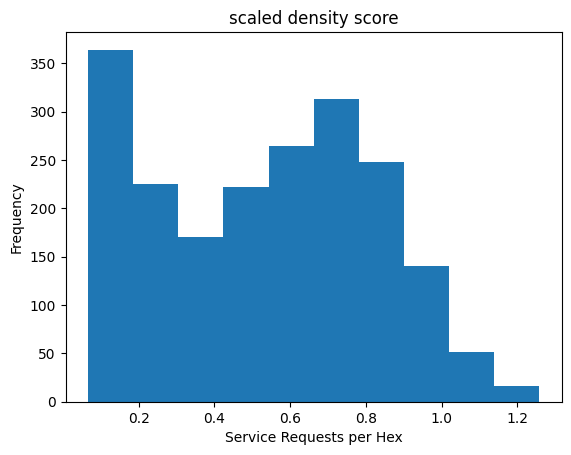

In [25]:
# Let's plot this

import matplotlib.pyplot as plt

plt.hist(per_hex_scaled['overall_scaling'])
plt.xlabel("Service Requests per Hex")
plt.ylabel("Frequency")
plt.title("scaled density score")
plt.show()

Ah, OK, I was hoping for a normal distribution, but we see a zero inflated normal, which is OK. I not the x-axis maximum extends beyond one; that's OK given the aporoach. 

I'm happy that the mean is around 0.5, which is what we'd expect because we are relatively classifying into Dense and Sparse Hexes -- approximately 50% should be in either classification. 

Now, let's define Densely/Sparsely population per Hex. One way of doing this is to simply take the mean of the distribution and anything above the median is Dense, anything below is Sparse. 

In [26]:
per_hex_scaled['classification'] = np.where(per_hex_scaled['overall_scaling'] > 0.55, 1, 0)
per_hex_scaled['classification'].value_counts() # Roughly 50/50 split. 

classification
1    1020
0     993
Name: count, dtype: int64

## Assessment 

Right, so let's assess our method and see if it aligns with our real-world experience. 

We currently only have the Hex ID as our spatial marker:

In [27]:
per_hex_scaled

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification
0,0.222222,0.692308,0.571429,0.052033,0.042112,88ad360001fffff,0.947967,0.632518,1
1,0.111111,0.384615,0.285714,0.032112,0.010676,88ad360003fffff,0.967888,0.370960,0
2,0.222222,0.692308,0.619048,0.045055,0.141459,88ad360005fffff,0.954945,0.707110,1
3,0.222222,0.769231,0.619048,0.050271,0.100534,88ad360007fffff,0.949729,0.705110,1
4,0.111111,0.000000,0.000000,0.035593,0.000000,88ad36000bfffff,0.964407,0.163107,0
...,...,...,...,...,...,...,...,...,...
2008,0.222222,0.307692,0.238095,0.021183,0.006228,88ad36d737fffff,0.978817,0.398688,0
2009,0.333333,0.538462,0.380952,0.079342,0.025208,88ad36d739fffff,0.920658,0.583015,1
2010,0.555556,0.538462,0.428571,0.116160,0.038553,88ad36d73bfffff,0.883840,0.734959,1
2011,0.111111,0.307692,0.285714,0.046617,0.032028,88ad36d73dfffff,0.953383,0.359244,0


We need to get back to suburb somehow. Remember, there isn't a 1:1 mapping back to suburb or to section. The simplest way to get what we want here is to create a DF of suburb and Hex, and then merge with our classified DataSet. There will be some duplication in the resultant merge on Hex and Classification, but it will be unique on Surburb

In [28]:
# unique combos of hex and suburb:
unique_combos = df[['h3_level8_index', 'official_suburb']].drop_duplicates()

# Merge
inspect_classifier = pd.merge(per_hex_scaled, unique_combos, left_on = "h3_level8_index", right_on = "h3_level8_index", how = "left")
inspect_classifier.shape

(4355, 10)

In [29]:
per_hex_scaled.shape # quit a bit of duplicaiton, but not on the suburb level. 

(2013, 9)

In [30]:
hex_ = unique_combos[unique_combos['official_suburb'].str.contains("Scarborough", case=False, na=False)]['h3_level8_index'].drop_duplicates()
sparse = inspect_classifier[inspect_classifier['h3_level8_index'].isin(hex_)]
sparse

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification,official_suburb
2798,0.222222,0.230769,0.238095,0.047181,0.006821,88ad368429fffff,0.952819,0.373367,0,CAPE FARMS - DISTRICT H
2799,0.222222,0.230769,0.238095,0.047181,0.006821,88ad368429fffff,0.952819,0.373367,0,SCARBOROUGH
2805,0.111111,0.538462,0.476190,0.048021,0.052491,88ad368461fffff,0.951979,0.497755,0,SCARBOROUGH
2806,0.222222,0.692308,0.666667,0.060197,0.120996,88ad368463fffff,0.939803,0.707604,1,SCARBOROUGH
2807,0.222222,0.692308,0.666667,0.060197,0.120996,88ad368463fffff,0.939803,0.707604,1,CAPE FARMS - DISTRICT H


Ah ok, mostly sparsely populated, but Hex (relating to the last 2 rows) being densely populated. This is mostly likely due to the num_departments and unique_code_groups being much higher here that the other Hexes. Ticekt numbers per Hex are essentially the same as the other Hexes. 


Let's try another Rural Area. Let's see if we can find "FARMS" in the unique_combos_df

In [31]:
unique_combos[unique_combos['official_suburb'].str.contains("farms", case=False, na=False)]

,h3_level8_index,official_suburb
129,88ad360a43fffff,CAPE FARMS - DISTRICT C
249,88ad36193dfffff,PAARL FARMS
369,88ad360147fffff,CAPE FARMS - DISTRICT C
753,88ad368c1bfffff,CAPE FARMS - DISTRICT H
796,88ad3685a9fffff,CAPE FARMS - DISTRICT H
...,...,...
929019,88ad360aebfffff,CAPE FARMS - DISTRICT C
929076,88ad361987fffff,CAPE FARMS - DISTRICT C
931852,88ad367289fffff,CAPE FARMS - DISTRICT B
936151,88ad3672c3fffff,CAPE FARMS - DISTRICT B


In [32]:
# Let's take the top 3: 
rural = ['88ad360a43fffff', '88ad36193dfffff', '88ad360147fffff']
rural_area = inspect_classifier[inspect_classifier['h3_level8_index'].isin(rural)]
rural_area

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification,official_suburb
124,0.222222,0.230769,0.142857,0.011977,0.002966,88ad360147fffff,0.988023,0.346003,0,CAPE FARMS - DISTRICT C
125,0.222222,0.230769,0.142857,0.011977,0.002966,88ad360147fffff,0.988023,0.346003,0,ATLAS GARDENS BUSINESS PARK
454,0.111111,0.076923,0.047619,0.003502,0.000297,88ad360a43fffff,0.996498,0.203857,0,CAPE FARMS - DISTRICT C
2044,0.111111,0.153846,0.142857,0.241616,0.001779,88ad36193dfffff,0.758384,0.232584,0,PAARL FARMS


OK, that is what we'd expect, all Hexes relating to FARMS are Classified as Sparse. 

Let's see if we can identify a Dense Hex -- one area I know is Dense is Green Point. Let's see what the Classification says:

In [33]:
hex_ = unique_combos[unique_combos['official_suburb'].str.contains("green point", case=False, na=False)]['h3_level8_index'].drop_duplicates()
hex_

759       88ad3615e9fffff
986       88ad3615c5fffff
1887      88ad361513fffff
2880      88ad3615ebfffff
3167      88ad361511fffff
3473      88ad361517fffff
42801     88ad3615e1fffff
230880    88ad3615edfffff
Name: h3_level8_index, dtype: str

In [34]:
hex_ = unique_combos[unique_combos['official_suburb'].str.contains("green point", case=False, na=False)]['h3_level8_index'].drop_duplicates()
dense = inspect_classifier[inspect_classifier['h3_level8_index'].isin(hex_)]
dense

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification,official_suburb
1503,0.333333,0.692308,0.809524,0.044137,0.223606,88ad361511fffff,0.955863,0.880299,1,BO-KAAP
1504,0.333333,0.692308,0.809524,0.044137,0.223606,88ad361511fffff,0.955863,0.880299,1,CAPE TOWN CITY CENTRE
1505,0.333333,0.692308,0.809524,0.044137,0.223606,88ad361511fffff,0.955863,0.880299,1,GREEN POINT
1506,0.222222,0.769231,0.666667,0.019231,0.168743,88ad361513fffff,0.980769,0.763425,1,GREEN POINT
1507,0.222222,0.769231,0.666667,0.019231,0.168743,88ad361513fffff,0.980769,0.763425,1,BO-KAAP
1510,0.333333,0.769231,0.666667,0.020992,0.083333,88ad361517fffff,0.979008,0.778670,1,GREEN POINT
1511,0.333333,0.769231,0.666667,0.020992,0.083333,88ad361517fffff,0.979008,0.778670,1,FORESHORE
1512,0.333333,0.769231,0.666667,0.020992,0.083333,88ad361517fffff,0.979008,0.778670,1,CAPE TOWN CITY CENTRE
1513,0.333333,0.769231,0.666667,0.020992,0.083333,88ad361517fffff,0.979008,0.778670,1,NaN
1583,0.333333,0.846154,0.761905,0.030668,0.336595,88ad3615c5fffff,0.969332,0.981308,1,GREEN POINT


This seems generally reasonable, except for the last 3 -- I would have expected "Mouille Point", "Green Point", and "Foreshore" to be Densely populated. These all related to one Hex (88ad3615edfffff), and if we compare it to other Hexs, we see that that it is tied for the highest number of ticket submissions ('subs'), but it's the lowest scoring Hex for 'num_departments', and 'unique_code_groups', but has a very low avg_completion_time score. That's the 2nd time we see **num_departments** and **unique_code_groups** influencing a wrong Classification. 

Let's try one more area -- Southern Suburbs (Newlands) is generally quite dense, let's see what the Classifier says:


In [35]:
hex_ = unique_combos[unique_combos['official_suburb'].str.contains("newlands", case=False, na=False)]['h3_level8_index'].drop_duplicates()
dense = inspect_classifier[inspect_classifier['h3_level8_index'].isin(hex_)]
dense

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification,official_suburb
1651,0.222222,0.846154,0.761905,0.024342,0.191578,88ad361701fffff,0.975658,0.828263,1,NEWLANDS
1652,0.222222,0.846154,0.761905,0.024342,0.191578,88ad361701fffff,0.975658,0.828263,1,TABLE MOUNTAIN
1653,0.222222,0.692308,0.619048,0.028678,0.125445,88ad361705fffff,0.971322,0.699139,1,RONDEBOSCH
1654,0.222222,0.692308,0.619048,0.028678,0.125445,88ad361705fffff,0.971322,0.699139,1,NEWLANDS
1655,0.222222,0.384615,0.333333,0.024880,0.011269,88ad361707fffff,0.975120,0.452992,0,NEWLANDS
1656,0.222222,0.384615,0.333333,0.024880,0.011269,88ad361707fffff,0.975120,0.452992,0,TABLE MOUNTAIN
1657,0.333333,0.769231,0.666667,0.022228,0.234875,88ad361709fffff,0.977772,0.869472,1,CLAREMONT
1658,0.333333,0.769231,0.666667,0.022228,0.234875,88ad361709fffff,0.977772,0.869472,1,BISHOPSCOURT
1659,0.333333,0.769231,0.666667,0.022228,0.234875,88ad361709fffff,0.977772,0.869472,1,NEWLANDS
1660,0.111111,0.615385,0.571429,0.018565,0.115658,88ad36170bfffff,0.981435,0.590249,1,NEWLANDS


Again, this looks reasonable. We are again getting some Hexes who should be Dense but are not ("88ad361707fffff"). Analysing the input variables, we see again  **num_departments** and **unique_code_groups** are low relative to the other hexes, and again are the cause for an inaccurate (seemingly -- I'd have to geographically check the region first) classifications. 

### Map this back

Let's try look at this through space, using the other data provided. 

In [36]:
import geopandas as gpd

# file location
file_path = "/Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/city-hex-polygons-8.geojson"

# geojson file
hex_gdf = gpd.read_file(file_path)

# insepct
print(hex_gdf.head())

# cols
print(hex_gdf.columns)

# hexs
print(f"Number of hexes: {len(hex_gdf)}")


             index  centroid_lat  centroid_lon  \
0  88ad361801fffff    -33.859427     18.677843   
1  88ad361803fffff    -33.855696     18.668766   
2  88ad361805fffff    -33.855263     18.685959   
3  88ad361807fffff    -33.851532     18.676881   
4  88ad361809fffff    -33.867322     18.678806   

                                            geometry  
0  POLYGON ((18.68119 -33.8633, 18.68357 -33.8592...  
1  POLYGON ((18.67211 -33.85957, 18.6745 -33.8555...  
2  POLYGON ((18.68931 -33.85914, 18.69169 -33.855...  
3  POLYGON ((18.68023 -33.85541, 18.68261 -33.851...  
4  POLYGON ((18.68215 -33.8712, 18.68454 -33.8671...  
Index(['index', 'centroid_lat', 'centroid_lon', 'geometry'], dtype='str')
Number of hexes: 3832


In [37]:
phx = pd.merge(per_hex_scaled, hex_gdf, left_on = "h3_level8_index", right_on = "index", how = "left")

In [38]:
phs = gpd.GeoDataFrame(phx, geometry='geometry')
phs

,subs,num_departments,unique_code_groups,avg_completion_time,num_requests,h3_level8_index,avg_completion_time_inv,overall_scaling,classification,index,centroid_lat,centroid_lon,geometry
0,0.222222,0.692308,0.571429,0.052033,0.042112,88ad360001fffff,0.947967,0.632518,1,88ad360001fffff,-33.836215,18.494066,"POLYGON ((18.4974 -33.84009, 18.49979 -33.8360..."
1,0.111111,0.384615,0.285714,0.032112,0.010676,88ad360003fffff,0.967888,0.370960,0,88ad360003fffff,-33.832471,18.485002,"POLYGON ((18.48834 -33.83635, 18.49073 -33.832..."
2,0.222222,0.692308,0.619048,0.045055,0.141459,88ad360005fffff,0.954945,0.707110,1,88ad360005fffff,-33.832062,18.502176,"POLYGON ((18.50552 -33.83594, 18.5079 -33.8319..."
3,0.222222,0.769231,0.619048,0.050271,0.100534,88ad360007fffff,0.949729,0.705110,1,88ad360007fffff,-33.828319,18.493112,"POLYGON ((18.49645 -33.8322, 18.49884 -33.8281..."
4,0.111111,0.000000,0.000000,0.035593,0.000000,88ad36000bfffff,0.964407,0.163107,0,88ad36000bfffff,-33.840366,18.485955,"POLYGON ((18.48929 -33.84425, 18.49168 -33.840..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.222222,0.307692,0.238095,0.021183,0.006228,88ad36d737fffff,0.978817,0.398688,0,88ad36d737fffff,-34.130931,18.883856,"POLYGON ((18.88721 -34.13479, 18.8896 -34.1307..."
2009,0.333333,0.538462,0.380952,0.079342,0.025208,88ad36d739fffff,0.920658,0.583015,1,88ad36d739fffff,-34.146671,18.885802,"POLYGON ((18.88916 -34.15053, 18.89155 -34.146..."
2010,0.555556,0.538462,0.428571,0.116160,0.038553,88ad36d73bfffff,0.883840,0.734959,1,88ad36d73bfffff,-34.142960,18.876697,"POLYGON ((18.88006 -34.14682, 18.88244 -34.142..."
2011,0.111111,0.307692,0.285714,0.046617,0.032028,88ad36d73dfffff,0.953383,0.359244,0,88ad36d73dfffff,-34.142512,18.893934,"POLYGON ((18.89729 -34.14637, 18.89968 -34.142..."


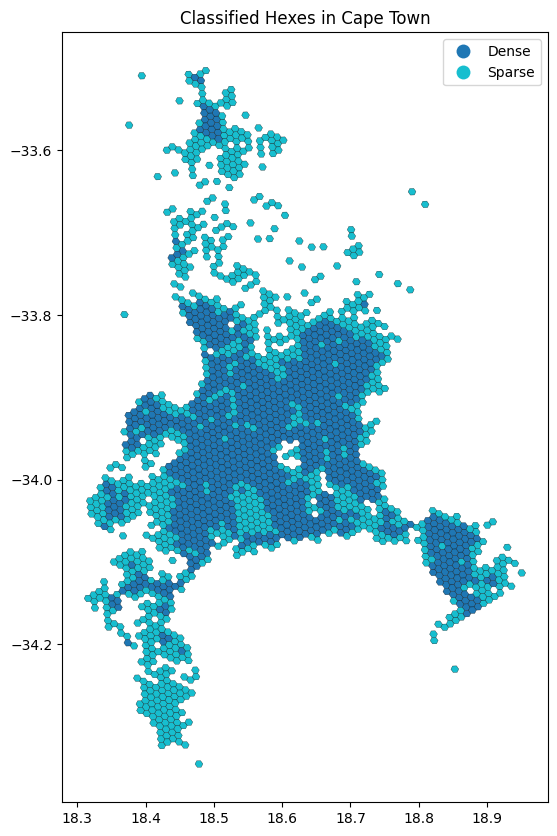

In [39]:
import matplotlib.pyplot as plt

phs['classification_label'] = phs['classification'].map({
    0: 'Sparse',
    1: 'Dense'
})

fig, ax = plt.subplots(figsize=(10,10))
phs.plot(
    column='classification_label',       
    #cmap='RdBu',
    legend=True,
    categorical=True,
    vmin=0,
    vmax=1,
    ax=ax,
    edgecolor='black',            
    linewidth=0.2
)
ax.set_title("Classified Hexes in Cape Town")
plt.show()

OK, this aligns with my understanding of the Geograph of CoCT -- the suburbs in and around the City, Stellenbosch, Muizenburg, etc are densely populated, and the sparsely populated areas being confined to the outskirts of the peninsula. A few gaps, too, in data, but looking reasonable on average. 

## 4. Improvements

There are many ways to improve upon this solution. 

**Assumptions**
I've made a lot of simplifying assumptions in the exercise, based on my own logic and reasoning. A good first measure of improving this classification would be to sense check these assumptions, ideally trying to validate them in the real-world. For example, that the rate of SR submission does vary with population size, or that time-to-completion of SR is indeed lower in densely-populated Hexes. 

For example, we note that the "Sparse" Classification of a Hex in Greenpoint, and another in Newlands, was due to low scores for num_departments and unique_code_groups. We would definitely have to relook at these weightings. Also, it may be that the total number of departments represented is not as important as the type of Department recorded. These considerations should be given to the method. 

**Weightings**
A second point which could improve on my approach is to work with the weighting in the linear combination approach to estimate classification per Hex. It's likely that my weightings don't reflect those of subject-matter experts, and could greatly be improved upon. 

I've also included and scaled the count and sum of variables included in the dataset. It may be the the standard deviation is a more reflective meausre that the mean or the count. 

**Spatial Autcorrelation**
I haven't taken into account here spatial autocorrelation, meaning that Hexes together are likely to be similar in metrics, than Hexes far apart. We could use this type of spatial information in the linear combination approach.

**Method**
I've gone with a simple linear combination method, but I could have used clustering methods (K-means, Heirarchical clustering, DBScan), or even Principal Components Analysis on the scaled features. These methods may be more accurate (but maybe less interprettable), but still would be worth examining. 
